# Minimization, constraints, and kinematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/05_minimization_constraints_kinematics.ipynb)

> **Prerequisite.** This notebook builds on the score-function and coordinate concepts in [Scoring and Analysis](03_scoring_and_analysis.ipynb). It introduces `MoveMap` and `FoldForest`, which the FastRelax tutorial reuses.

## Goals

By the end of this tutorial you will be able to:

- minimize a small, checked-in 1ubq slice in Cartesian and kinematic coordinates;
- restrict motion with `CartesianMoveMap` and `MoveMap`;
- construct and inspect a `FoldForest` edge tensor;
- add tested coordinate constraints through `ConstraintSet`/`ConstraintEnergyTerm` utilities; and
- compare energies and coordinate displacements for constrained and unconstrained runs.

All examples use fixed seeds and repository fixtures. The notebook intentionally does not fetch structures or parameters from the network.

## Setup

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.kinematics.fold_forest import EdgeType, FoldForest
from tmol.kinematics.move_map import CartesianMoveMap, MoveMap
from tmol.optimization.minimizers import run_cart_min, run_kin_min
from tmol.score.constraint.utility import create_mainchain_coordinate_constraints
from tmol.score.score_types import ScoreType
from tmol.score.score_utils import build_sidechain_coord_mask

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def show_table(frame):
    """Use a sortable docs table when available, otherwise display pandas."""
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def total_score(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    return float(scorer(pose_stack.coords).detach().cpu()[0])


def rms_displacement(reference, mobile, atom_mask=None):
    finite = torch.isfinite(reference.coords).all(dim=-1)
    finite &= torch.isfinite(mobile.coords).all(dim=-1)
    mask = finite if atom_mask is None else finite & atom_mask
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())

## Build a small pose and inspect its FoldForest

`FoldForest.reasonable_fold_forest()` derives polymer and jump edges from backbone connectivity. Each edge is `(type, start block, end block, jump index)`. The edge array is batched over poses.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 8)]
start = pose_stack_from_biotite(protein_slice, device, no_optH=True)

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fold_forest = FoldForest.reasonable_fold_forest(start)

edge_names = {int(edge): edge.name for edge in EdgeType}
edge_rows = []
for pose_i in range(start.n_poses):
    for edge_i in range(int(fold_forest.n_edges[pose_i])):
        edge_type, begin, end, jump_index = fold_forest.edges[pose_i, edge_i]
        edge_rows.append(
            {
                "pose": pose_i,
                "edge": edge_i,
                "type": edge_names[int(edge_type)],
                "start": int(begin),
                "end": int(end),
                "jump_index": int(jump_index),
            }
        )

print("input:", cif_path.name)
print("FoldForest edge tensor shape:", fold_forest.edges.shape)
show_table(pd.DataFrame(edge_rows))

input: 1UBQ.cif
FoldForest edge tensor shape: (1, 2, 4)


**Expected observations.** The edge table should contain an explicit `root_jump` whose start is `-1`, followed by polymer edges covering the contiguous 1UBQ slice. Missing or overlapping block ranges indicate a malformed forest and should be investigated before minimization.

TMol's `FoldForest` differs from Rosetta's `FoldTree` in one important invariant: every TMol forest has an explicit virtual root at the origin. `reasonable_fold_forest()` follows backbone up/down connections, turns same-chain gaps into jumps, and roots separate chains independently. Its current automatic builder intentionally ignores non-polymer connections such as disulfides.

## Executable constrained and unconstrained workflow

`run_cart_min` accepts `(pose_stack, sfxn, coord_mask=None, optimizer_cls=..., optimizer_kwargs=None, verbose=False)`. `run_kin_min` accepts `(pose_stack, sfxn, ff, mm, optimizer_cls=..., optimizer_kwargs=None, verbose=False, kin_dtype=...)`.

The tensorized `create_mainchain_coordinate_constraints()` utility constructs a `ConstraintSet` with `ConstraintEnergyTerm.harmonic_coordinate` restraints anchored to the starting main-chain atom positions. The score-function constraint weight controls whether those restraints contribute.

PR #399 includes a one-line shape fix for the simpler `constrain_all_ca()` helper. Until that PR is integrated, this executable tutorial uses the working main-chain utility rather than duplicating the fix on the documentation branch.

In [4]:
cartesian_move_map = CartesianMoveMap(
    coord_mask=torch.isfinite(start.coords).all(dim=-1)
)
kinematic_move_map = MoveMap.from_pose_stack(start)
kinematic_move_map.move_all_named_torsions = True
kinematic_move_map.move_all_jumps = False

constrained_start = create_mainchain_coordinate_constraints(start.clone())
optimizer_kwargs = {"max_iter": 10}

cart_unconstrained = run_cart_min(
    start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
cart_constrained = run_cart_min(
    constrained_start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
kin_unconstrained = run_kin_min(
    start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)
kin_constrained = run_kin_min(
    constrained_start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)

pose_ind_for_real_mc_at torch.Size([24])
block_for_real_mc_at torch.Size([24])
local_atom_ind_for_real_mc_at torch.Size([24])
constr_atoms torch.Size([24, 1, 3])


/home/runner/work/tmol/tmol/tmol/score/constraint/constraint_energy_term.py:465: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  sparse_scores = torch.sparse_coo_tensor(


/tmp/ipykernel_3148/1007658205.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


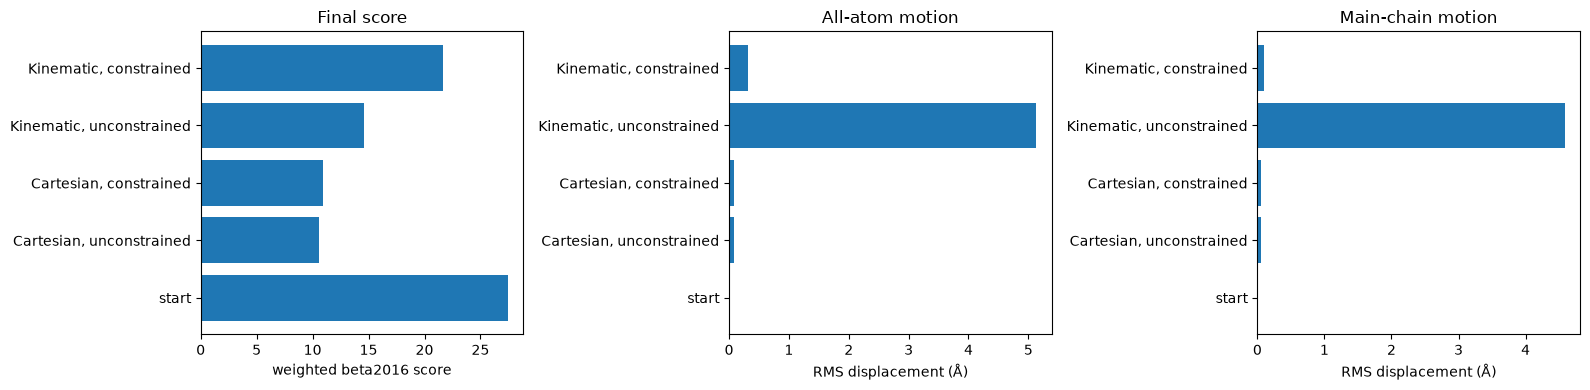

In [5]:
variants = {
    "Cartesian, unconstrained": cart_unconstrained,
    "Cartesian, constrained": cart_constrained,
    "Kinematic, unconstrained": kin_unconstrained,
    "Kinematic, constrained": kin_constrained,
}
sidechain_mask = build_sidechain_coord_mask(start)
mainchain_mask = start.real_atoms & ~sidechain_mask
rows = [
    {
        "variant": "start",
        "weighted_energy": total_score(start, score_function),
        "all_atom_RMS_displacement_A": 0.0,
        "mainchain_RMS_displacement_A": 0.0,
    }
]
for name, pose_stack in variants.items():
    rows.append(
        {
            "variant": name,
            "weighted_energy": total_score(pose_stack, score_function),
            "all_atom_RMS_displacement_A": rms_displacement(start, pose_stack),
            "mainchain_RMS_displacement_A": rms_displacement(
                start, pose_stack, mainchain_mask
            ),
        }
    )
comparison_frame = pd.DataFrame(rows)
show_table(comparison_frame)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].barh(comparison_frame["variant"], comparison_frame["weighted_energy"])
axes[0].set(xlabel="weighted beta2016 score", title="Final score")
axes[1].barh(
    comparison_frame["variant"], comparison_frame["all_atom_RMS_displacement_A"]
)
axes[1].set(xlabel="RMS displacement (Å)", title="All-atom motion")
axes[2].barh(
    comparison_frame["variant"], comparison_frame["mainchain_RMS_displacement_A"]
)
axes[2].set(xlabel="RMS displacement (Å)", title="Main-chain motion")
plt.tight_layout()
plt.show()

viewer_structures = {"before": start, **variants}
viewer_notes = {"before": "Starting 1UBQ slice"}
for row in rows[1:]:
    viewer_notes[row["variant"]] = (
        f"score {row['weighted_energy']:.3f}; "
        f"main-chain motion {row['mainchain_RMS_displacement_A']:.3f} Å"
    )
display(tmol.switchable_view(viewer_structures, notes=viewer_notes))

**Expected observations.** Every minimized structure should have finite score and displacement values. The all-atom column includes repacked side chains; the main-chain column measures exactly the atoms restrained by this workflow. Coordinate restraints should generally reduce main-chain motion relative to the matching unconstrained parameterization, but Cartesian and kinematic minima need not agree. A higher final score is not automatically a failure when the constraint term deliberately trades physical-score improvement for positional fidelity.

## Rosetta comparison

Rosetta's `MinMover` and Cartesian minimization use a `MoveMap` to select internal or Cartesian degrees of freedom. TMol separates these concepts into `MoveMap` for named torsion/jump DOFs and `CartesianMoveMap` for a per-atom coordinate mask. TMol's tensor representation applies those selections across a `PoseStack` batch.

Rosetta `FoldTree` can choose a physical residue as the root and represents chemical and jump connectivity within one tree. TMol `FoldForest` is batched and always has a virtual root at the origin. The automatic TMol builder currently follows polymer connectivity and ignores disulfides; construct and validate custom edges when that limitation matters.

Rosetta accepts rich text constraint files and ambiguous/multi constraints. TMol currently has no Rosetta constraint-file parser and no ambiguous-constraint layer. Its built-in tested functions are harmonic distance/coordinate, bounded distance, and circular-harmonic torsion constraints assembled directly through `ConstraintSet` and `ConstraintEnergyTerm`. TMol currently has no dedicated three-atom angle-constraint function.

## Limitations

- These are local minimizers, not global conformational searches.
- Cartesian and kinematic runs optimize different parameterizations, so their final energies and displacements need not match.
- `reasonable_fold_forest()` is a convenience builder, not a full Rosetta FoldTree inference engine; non-polymer/disulfide connections are ignored.
- Constraint APIs are tensor-native. There is no constraint-file parser, ambiguous constraint, atom-pair selector, or general Rosetta `Func` hierarchy.
- The table checks qualitative behavior. Exact energies are device-, dtype-, and optimizer-sensitive and should not be used as golden documentation values.

## Exercises

1. Change the Cartesian coordinate mask so only residues 3–5 move, then compare the displacement table.
2. Disable side-chain torsions in the kinematic `MoveMap` and enable only main-chain torsions for selected blocks.
3. Replace the coordinate restraints with a tested `ConstraintEnergyTerm.bounded` distance constraint.
4. Build a two-chain slice and identify each virtual-root edge in the edge tensor.
5. Sweep the harmonic standard deviation and plot restraint energy against RMS displacement.

## References

- [Rosetta minimization tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/minimization/minimization)
- [Rosetta constraints tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Constraints_Tutorial/Constraints)
- [Rosetta FoldTree tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/fold_tree/fold_tree)
- [Rosetta `FoldTree.hh`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/kinematics/FoldTree.hh)
- [Rosetta `ConstraintSet.cc`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/scoring/constraints/ConstraintSet.cc)